# Machine Learning Interatomic Potentials

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PhilipVinc/ComputationalQuantumPhysics/blob/main/Notebooks/6-Elecs/3-MLMD.ipynb)

Last week we ran Born–Oppenheimer Molecular Dynamics. 
At each time step we solved the electronic Schrödinger equation to a good approximation with exact diagonalisation or some other advanced method implemented in PySCF to obtain forces. 
This is accurate but **very expensive**, as it requires one DFT/HF call per step and it limited the size and times that we could reach.

The lesson of today is to show that Machine Learning method allow to solve this limitation. 
It is possible to learn the potential energy surface $E(\mathbf{R})$ from a SMALL set of pre-computed configurations, and use the learned model as a fast surrogate for the expensive quantum-chemistry calculation.
This technique is known as **machine learning interatomic potentials (MLIPs)**. 

The key tools we will be working with are **supervised learning** and **Graph Neural Network (GNN)** architectures that respects the physical symmetries of the Potential Energy Surface (PES). 
Once trained, the GNN evaluates in microseconds rather than seconds — a $10^3$–$10^6$ speedup that makes long MD trajectories feasible.

A key point that was discovered rather early in the story of Machine Learning Potential was that models must be equivariant under transformations that maintain the same structure of the atoms. 
In practice, it's vitally important that the following property holds

$$E(\mathbf{R}) = E(O\mathbf{R} + \mathbf{t}) \quad \forall\; \text{rotation}\; O,\; \text{translation}\; \mathbf{t}$$

Meaning that if we rotate the postions of the atoms around the origin, or translate the atoms in the same way alltogether, the energy does not change.


**Plan:**
The plan for today is the following: 
1. **Dataset** — First you'll load and inspect a library of $H_2$/$H_4$ configurations labelled with energies and forces. I generated those with a short script using PyScf. Generating the dataset took a few minutes and you don't have to do it. In general this takes much longer for more complex problems.
2. **Architecture** — We will be using a Machine Learning Potential Based on the Graph Neural Network architecture known as "SchNet". We will use a small network implemented in JAX.
3. **Training** — We will fit the GNN to energies *and* it's derivative to the forces present in the dataset. Then we will inspect the accuracy of the result.
4. **ML-MD** — run Langevin dynamics using the GNN as force oracle; compute and compare observable properties.

In [17]:
# Uncomment on Colab to install packages:
# !pip install flax optax pyscf

In [18]:
import jax

import numpy as np
import matplotlib.pyplot as plt

import jax.numpy as jnp
import flax.linen as nn
import optax
from pyscf import gto, scf

print("JAX is running on:", jax.devices())

# ── Physical constants ──────────────────────────────────────────────
MASS_H       = 1836.15267    # proton mass in electron masses (a.u.)
BOHR_TO_ANG  = 0.529177      # 1 Bohr in Angstrom
K_BOLTZMANN  = 3.1668e-6     # Ha / K
EH_TO_MEV    = 27211.4       # 1 Ha in meV
AU_TIME_FS   = 0.02419       # 1 a.u. time in femtoseconds
AU_FREQ_CM1  = 219474.6      # 1 a.u. angular frequency in cm^{-1}

# ── Dataset parameters ──────────────────────────────────────────────
E_H_ISOLATED = -0.46658182   # RHF/STO-3G energy of isolated H atom (Ha)
MAX_ATOMS    = 4             # all configs are padded to this size

# Ghost atoms must be at DISTINCT far-away positions — if two ghosts
# were at the same point the pairwise distance r=0 would cause NaN gradients.
GHOST_POSITIONS = np.array([
    [1000., 0., 0.],
    [0., 1000., 0.],
    [0., 0., 1000.],
], dtype=np.float32)  # shape (3, 3) — up to 3 ghost atoms


JAX devices: [CpuDevice(id=0)]



---
## Part 1 — The Dataset

The file `h_dataset.npz` contains 1200 configurations of hydrogen atoms (**$H_2$** and **$H_4$**), generated by running PySCF RHF/STO-3G on random geometries.  ($H_3$ has an odd number of electrons and would require open-shell methods, which are somewhat more complex than what we discussed last week)

All configurations are padded to `MAX_ATOMS = 4` entries; If a configuration has less than `MAX_ATOMS` the extra atoms are positioned artificially at the `GHOST_POSITIONS` (axis-aligned far positions $\ge 1000$ Bohr), well beyond the interaction cutoff so that their interaction energy is 0.

| Key | Shape | Units | Description |
|-----|-------|-------|-------------|
| `positions` | $(N, 4, 3)$ | Bohr | nuclear coordinates (padded) |
| `energies`  | $(N,)$ | Ha | *interaction* energy $E_{\rm tot} - N_H \cdot E_H$ |
| `forces`    | $(N, 4, 3)$ | Ha/Bohr | forces $\mathbf{F}=-\partial E/\partial \mathbf{R}$ (zero for ghosts) |
| `n_atoms`   | $(N,)$ | — | actual number of H atoms (2 or 4) |

The **interaction energy** is defined as:
$$E_{\rm int} = E_{\rm tot} - N_H \cdot E_{\rm H,\,iso}$$
where $E_{\rm H,\,iso} \approx -0.46658$ Ha is the RHF/STO-3G energy of an isolated H atom.  This zeros out the asymptote and makes the learning target small (order $10^{-1}$ Ha).


In [19]:
# ================================================================
# DATASET GENERATION  (already done — change False→True to redo)
# ================================================================
# The script generate_h_dataset.py reproduces h_dataset.npz.
# It takes ~5-10 min on a laptop CPU. 
# You don't need to run it. But if you're curious, you can run it yourself.

if False:
    from generate_h_dataset import main as _gen
    _gen()

In [25]:
print("loading dataset...")
data      = np.load('h_dataset.npz')
print("dataset loaded. Has keys:", data.files)
positions = data['positions']   # (N, 4, 3) Bohr  — padded
energies  = data['energies']    # (N,)      Ha    — interaction energy
forces    = data['forces']      # (N, 4, 3) Ha/Bohr
n_atoms   = data['n_atoms']     # (N,)      int  (2 or 4)

# Boolean mask: True for real atoms, False for ghosts
real_mask = (np.arange(MAX_ATOMS)[None, :] < n_atoms[:, None]).astype(np.float32)
# shape (N, 4): [1,1,0,0] for H2, [1,1,1,1] for H4

print(f"Dataset: {len(energies)} total configurations")
print(f"  H2: {(n_atoms==2).sum()},  H4: {(n_atoms==4).sum()}")
print(f"  Energy range (interaction): [{energies.min():.3f}, {energies.max():.3f}] Ha")
print(f"  Max |force|:  {np.linalg.norm(forces.reshape(-1,3), axis=1).max():.3f} Ha/Bohr")


loading dataset...
dataset loaded. Has keys: ['positions', 'energies', 'forces', 'n_atoms', 'e_h_isolated']
Dataset: 1199 total configurations
  H2: 800,  H4: 399
  Energy range (interaction): [-1.083, 0.159] Ha
  Max |force|:  3.286 Ha/Bohr



### Task 1 — Inspect the dataset

**(a)** For the **$H_2$ configurations only**, compute the interatomic distance $r$ for each sample and make two plots:
  - $E_{\rm int}(r)$ in meV vs distance in Å — identify the equilibrium distance $r_{\rm eq}$
  - $|\mathbf{F}_0|(r)$ in Ha/Bohr vs distance — where is it zero? positive? negative?

**(b)** Print the equilibrium distance found in the dataset and compare with the experimental value 0.741 Å.

**(c)** For the **$H_4$ configurations**, compute the shortest pairwise distance in each configuration and plot a histogram.  What does it tell you about the geometry diversity?

**Hints:**
- `h2_mask = (n_atoms == 2)` selects H2 configs
- `r = np.linalg.norm(positions[h2_mask, 0] - positions[h2_mask, 1], axis=1)`
- Sort before plotting: `s = np.argsort(r); plt.plot(r[s]*BOHR_TO_ANG, E[s]*EH_TO_MEV)`


In [ ]:
# ── Task 1 ──────────────────────────────────────────────────────────
h2_mask = (n_atoms == 2)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) H2 distances and energies
# --- your code here ---
#axes[0].plot()

# (b) Print equilibrium distance
# --- your code here ---
# axes[1].plot(...)

# (c) H3 geometry scatter
# --- your code here ---
# axes[2].scatter(...)

Below we take the dataset and we split it into a training / validation and testing sets. 
Our target ratios are to keep 80% of the dataset for training, 10% of the dataset for validation and 10% for testing.

In [33]:
# ── Provided: train / validation / test split ────────────────────────
rng_split = np.random.default_rng(seed=0)
idx       = rng_split.permutation(len(energies))
n_tr      = int(0.80 * len(idx))
n_va      = int(0.10 * len(idx))

tr_idx, va_idx, te_idx = idx[:n_tr], idx[n_tr:n_tr+n_va], idx[n_tr+n_va:]

train_pos,  train_E,  train_F,  train_mask  = (positions[tr_idx], energies[tr_idx],
                                                forces[tr_idx],   real_mask[tr_idx])
val_pos,    val_E,    val_F,    val_mask    = (positions[va_idx], energies[va_idx],
                                                forces[va_idx],   real_mask[va_idx])
test_pos,   test_E,   test_F,   test_mask   = (positions[te_idx], energies[te_idx],
                                                forces[te_idx],   real_mask[te_idx])

print("Dataset split:")
print(f"Train: {len(tr_idx)},  Val: {len(va_idx)},  Test: {len(te_idx)}")

Dataset split:
Train: 959,  Val: 119,  Test: 121


<div style="
	display:grid;
	grid-template-columns:minmax(620px, 1.05fr) minmax(380px, 1fr);
	gap:48px;
	align-items:start;
	max-width:1300px;
	margin:0 auto;
">

<div style="min-width:0; line-height:1.5;">

## Part 2 — The Graph Neural Network

We will be using today a simplified version of [SchNet (Schütt et al. 2017)](https://arxiv.org/abs/1712.06113) or [the published version](https://pubs.aip.org/aip/jcp/article-abstract/148/24/241722/962591/SchNet-A-deep-learning-architecture-for-molecules). 
This architecture is built on top of:

The potential energy surface must be invariant under:
- **Translations:** $E(\mathbf{R}+\mathbf{t}) = E(\mathbf{R})$
- **Rotations:** $E(O\mathbf{R}) = E(\mathbf{R})$ for any rotation $O\in SO(3)$
- **Permutations** of identical atoms: $E(\ldots, \mathbf{R}_i, \ldots, \mathbf{R}_j, \ldots) = E(\ldots, \mathbf{R}_j, \ldots, \mathbf{R}_i, \ldots)$

**1. Pairwise Distances:**
A way to construct a function $f(R_1, \dots, R_N)$ that is invariant under all those transformations above is to... change the input of the function!
**Pairwise distances** $$r_{ij} = |\mathbf{R}_i - \mathbf{R}_j|$$ are manifestly invariant under the three symmetries above (if you don't see it, prove it!), so that if our potential function $f(r_{11}, r_{12}, \dots, r_{NN})$ depends only on those coordinates, it is also automatically invariant under the simmetries above.

**2. RBF Layer:**
The neural network therefore receives only these distances as geometric inputs.
Distances are first expanded into a **radial basis representation (RBF)** that provides a smooth, learnable encoding of the local environment. For each pair we compute

$$
\phi_k(r_{ij}) =
\exp\!\left[-\gamma (r_{ij}-\mu_k)^2\right]
\, f_{\mathrm{cut}}(r_{ij}),
$$

where $\mu_k$ are evenly spaced centers and $f_{\mathrm{cut}}$ is a smooth cosine cutoff

$$
f_{\mathrm{cut}}(r) =
\begin{cases}
\tfrac12\left[\cos(\pi r / r_{\rm cut})+1\right], & r < r_{\rm cut}, \\
0, & r \ge r_{\rm cut}.
\end{cases}
$$

The cutoff ensures that interactions smoothly vanish beyond $r_{\rm cut}$.

**3. Embedding initialization:**
Each atom $i$ carries a learned **feature vector** $\mathbf h_i^{(l)} \in \mathbb{R}^F$.  
Since the dataset contains only hydrogen atoms, all atoms start from the same embedding

$$
\mathbf h_i^{(0)} = \mathbf h_{\text{H}} .
$$

Information propagates through the system via a sequence of **interaction (message-passing) blocks**. 

**4. Filter network:**
For every pair $(i,j)$, the RBF features are processed by a small neural network producing a **distance-dependent filter**

$$
\mathbf W_{ij} = W\!\left(\boldsymbol{\phi}(r_{ij})\right).
$$

**5. Edge Messages:**
Messages from neighboring atoms are then computed as

$$
\mathbf m_{ij} = \mathbf h_j^{(l)} \odot \mathbf W_{ij},
$$

where $\odot$ denotes element-wise multiplication.  

**6. Atom (vertex) update:**
All incoming messages are aggregated with a pooling (sum) operation to ensure the equivariance under permutation, and the atomic features are updated through a small MLP with a residual connection

$$
\mathbf h_i^{(l+1)} =
\mathbf h_i^{(l)} + \mathrm{MLP}(\sum_{j\ne i} \mathbf m_{ij}).
$$

Stacking several such layers allows information to propagate across the molecular graph.

**7. Readout composition:**
Finally, each atom contributes a **local energy**

$$
e_i = \mathrm{MLP}(\mathbf h_i),
$$

**8. Sum over atoms:**
and the total molecular energy is obtained through the permutation-invariant sum

$$
E(\mathbf R) = \sum_i e_i .
$$

Padding atoms (“ghost atoms”) are placed far away; because the cutoff function vanishes at large distances, they produce no interactions and can be masked out in the final sum.

</div>

<div style="min-width:0;">
<div style="position:sticky; top:20px;">
<div style="width:100%; max-width:700px; margin:0 auto;">

<svg xmlns="http://www.w3.org/2000/svg" width="680" viewBox="0 -60 680 760">
<defs>
  <marker id="arrow" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse">
    <path d="M2 1L8 5L2 9" fill="none" stroke="#888780" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/>
  </marker>
  <marker id="arrow-dashed" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse">
    <path d="M2 1L8 5L2 9" fill="none" stroke="#B4B2A9" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/>
  </marker>
  <style>
    .box-gray   { fill:#F1EFE8; stroke:#5F5E5A; }
    .box-teal   { fill:#E1F5EE; stroke:#0F6E56; }
    .box-purple { fill:#EEEDFE; stroke:#534AB7; }
    .box-coral  { fill:#FAECE7; stroke:#993C1D; }
    .title      { font-size:14px; font-weight:600; }
    .title-gray   { fill:#444441; }
    .title-teal   { fill:#085041; }
    .title-purple { fill:#3C3489; }
    .title-coral  { fill:#712B13; }
    .sub        { font-size:12px; }
    .sub-gray   { fill:#5F5E5A; }
    .sub-teal   { fill:#0F6E56; }
    .sub-purple { fill:#534AB7; }
    .sub-coral  { fill:#993C1D; }
    .muted      { font-size:12px; fill:#888780; }
    .arr        { stroke:#888780; stroke-width:1.5; fill:none; }
    .arr-dashed { stroke:#B4B2A9; stroke-width:1; stroke-dasharray:4 3; fill:none; }
    .sep        { stroke:#D3D1C7; stroke-width:0.5; stroke-dasharray:2 4; }
  </style>
</defs>

<!-- LEFT BRANCH -->
<rect x="40" y="-50" width="260" height="60" rx="8" stroke-width="0.5" class="box-gray"/>
<text class="title title-gray" x="170" y="-25" text-anchor="middle" dominant-baseline="central">positions</text>
<text class="sub sub-gray" x="170" y="-5" text-anchor="middle" dominant-baseline="central">shape: (B, A, 3)</text>
<line x1="170" y1="10" x2="170" y2="38" class="arr" marker-end="url(#arrow)"/>

<rect x="40" y="40" width="260" height="60" rx="8" stroke-width="0.5" class="box-gray"/>
<text class="title title-gray" x="170" y="62" text-anchor="middle" dominant-baseline="central">(1) Pairwise distances rᵢⱼ</text>
<text class="sub sub-gray" x="170" y="82" text-anchor="middle" dominant-baseline="central">shape: (B, P) </text>
<line x1="300" y1="72" x2="328" y2="72" class="arr" marker-end="url(#arrow)"/>
<line x1="170" y1="100" x2="170" y2="188" class="arr" marker-end="url(#arrow)"/>

<rect x="40" y="188" width="260" height="72" rx="8" stroke-width="0.5" class="box-teal"/>
<text class="title title-teal" x="170" y="210" text-anchor="middle" dominant-baseline="central">(2) RBF layer ϕₖ(rᵢⱼ) </text>
<text class="sub sub-teal" x="170" y="230" text-anchor="middle" dominant-baseline="central">Gaussian basis + cosine cutoff</text>
<text class="sub sub-teal" x="170" y="248" text-anchor="middle" dominant-baseline="central">shape: (B, P, K) </text>
<line x1="300" y1="224" x2="326" y2="224" class="arr-dashed" marker-end="url(#arrow-dashed)"/>

<!-- RIGHT BRANCH -->
<rect x="328" y="30" width="270" height="84" rx="8" stroke-width="0.5" class="box-purple"/>
<text class="title title-purple" x="463" y="54" text-anchor="middle" dominant-baseline="central">(3) Atom embeddings (zero-init)</text>
<text class="sub sub-purple" x="463" y="74" text-anchor="middle" dominant-baseline="central">nn.Embed of initial configuration</text>
<text class="sub sub-purple" x="463" y="94" text-anchor="middle" dominant-baseline="central">shape: (B, A, F) </text>
<line x1="463" y1="114" x2="463" y2="156" class="arr" marker-end="url(#arrow)"/>
<line x1="463" y1="156" x2="463" y2="184" class="arr" marker-end="url(#arrow)"/>


<!-- Interaction block container -->
<rect x="310" y="156" width="330" height="348" rx="12" fill="none" stroke="#B4B2A9" stroke-width="1" stroke-dasharray="5 3"/>
<text class="muted" x="328" y="174" dominant-baseline="central">× n_interactions</text>

<!-- Block 1 -->
<rect x="328" y="188" width="270" height="70" rx="8" stroke-width="0.5" class="box-coral"/>
<text class="title title-coral" x="463" y="210" text-anchor="middle" dominant-baseline="central">(4) Filter network  Wᶠᵢⱼ = W(ϕₖ(rᵢⱼ))</text>
<text class="sub sub-coral" x="463" y="230" text-anchor="middle" dominant-baseline="central">Dense→SiLU→Dense</text>
<text class="sub sub-coral" x="463" y="248" text-anchor="middle" dominant-baseline="central">shape: (B, P, F)</text>
<line x1="463" y1="258" x2="463" y2="278" class="arr" marker-end="url(#arrow)"/>

<rect x="328" y="280" width="270" height="70" rx="8" stroke-width="0.5" class="box-coral"/>
<text class="title title-coral" x="463" y="302" text-anchor="middle" dominant-baseline="central">(5) Message passing + aggregate</text>
<text class="sub sub-coral" x="463" y="322" text-anchor="middle" dominant-baseline="central">msgsᶠᵢⱼ = hⱼ·Wᶠᵢⱼ → scatter-add</text>
<text class="sub sub-coral" x="463" y="340" text-anchor="middle" dominant-baseline="central">shape: (B, A, F)</text>
<line x1="463" y1="350" x2="463" y2="370" class="arr" marker-end="url(#arrow)"/>

<rect x="328" y="372" width="270" height="70" rx="8" stroke-width="0.5" class="box-coral"/>
<text class="title title-coral" x="463" y="394" text-anchor="middle" dominant-baseline="central">(6) Atom update (residual)</text>
<text class="sub sub-coral" x="463" y="414" text-anchor="middle" dominant-baseline="central">h ← h + MLP(msgsᶠᵢⱼ)</text>
<text class="sub sub-coral" x="463" y="432" text-anchor="middle" dominant-baseline="central">shape: (B, A, F)</text>
<line x1="330" y1="454" x2="638" y2="454" class="sep"/>

<!-- Residual connection block 1 -->
<line x1="463" y1="168" x2="620" y2="168" class="arr"/>
<line x1="620" y1="168" x2="620" y2="448" class="arr"/>
<line x1="620" y1="448" x2="463" y2="448" class="arr" marker-end="url(#arrow)"/>


<!-- Block 2 collapsed -->
<line x1="463" y1="442" x2="463" y2="470" class="arr" marker-end="url(#arrow)"/>
<text class="muted" x="463" y="482" text-anchor="middle" dominant-baseline="central">… repeat once more …   shape: (B, A, F)</text>
<line x1="463" y1="506" x2="463" y2="536" class="arr" marker-end="url(#arrow)"/>

<!-- Readout -->
<rect x="328" y="538" width="260" height="72" rx="8" stroke-width="0.5" class="box-purple"/>
<text class="title title-purple" x="463" y="560" text-anchor="middle" dominant-baseline="central">(7) Readout MLP</text>
<text class="sub sub-purple" x="463" y="580" text-anchor="middle" dominant-baseline="central">Dense(F/2)→SiLU→Dense(1)</text>
<text class="sub sub-purple" x="463" y="598" text-anchor="middle" dominant-baseline="central">shape: (B, A)</text>
<line x1="463" y1="610" x2="463" y2="638" class="arr" marker-end="url(#arrow)"/>


<!-- Sum -->
<rect x="328" y="640" width="260" height="60" rx="8" stroke-width="0.5" class="box-gray"/>
<text class="title title-gray" x="463" y="662" text-anchor="middle" dominant-baseline="central">(8) Sum over atoms</text>
<text class="sub sub-gray" x="463" y="682" text-anchor="middle" dominant-baseline="central">shape: (B,)</text>

</svg>

</div>
</div>
</div>
</div>
</div>

In [ ]:
# Implementing the network yourself is... complicated. So I have pity on you and provide it.
# See schnet.py for the implementation. You should try to get a feeling of how it works, by following the schematic discused above

# add import path the path of the notebook to allow importing schnet.py
import sys
sys.path.append('.')

# actually import the NN Potential architeture
from schnet import SchNetPotential

# Note: the architecture takes those inputs with those default values

# The number of features in the continuous-filter convolution layers. This corresponds to the "width" of the network. Larger is more powerful but also more expensive.
# n_features:     int

# The depth of the network, or number of interaction blocks. Larger is more powerful but also more expensive.
# n_interactions: int

# The number of radial basis functions used to expand the pairwise distances. Larger is more powerful but also more expensive.
# n_rbf:          int 

# The cutoff distance for the pairwise interactions. Larger is more powerful but also more expensive.
# r_cut:          float


The architecture takes 2 inputs: 
 - the positions of the nuclei in the form of a matrix ``(Batch, MAX_ATOMS, 3)`` where for each batch we feed for each atom the x,y,z components of the position.
 - A binary mask of size ``(Batch, MAX_ATOMS)`` which contains 1s and 0s to label the 'valid' configurations. For example, if we have a configuration with only 2 atoms, we could use ``[1, 1, 0, 0]``.

### Task 2 — Constructing the model and inspecting it

Construct a 'small' model with **32 features**, **depth 3** and **20 gaussians in the radial basis expansion**, and using a cutoff of **6 a.u.** .
- Reminder: to define the model architecture you can do ``model = SchNetPotential(n_features=..., **other_kw_args...)` . This does not initialise the weights of the NN.
- Reminder: to generate some initial random weights for the network you need to call ``params = model.init(key, dummy_pos, dummy_mask)`` with some ``dummy_pos`` which is some random position (it's not important what it is, it's just used to know the shape of the inputs) and ``dummy_mask`` object which is used to define what atoms are 'valid' and which are not.
- Reminder: to evaluate the network you can use ``model.apply(params, positions, mask)``.

**(a)** Initialise the model with the hyperparameter given above,  **count the total number of trainable parameters** and try to perform a forward pass and see the energy for a random configuration.

**(b)** Define a function ``compute_energy_and_forces`` with the signature as below that computes both the energy and the forces. Prefer to `jax.jit` compile it if possible
```python
def compute_energy_and_forces(model, params, positions, real_mask) -> tuple[float, jax.Array]:
    '''Return (energy_float, forces_array) via automatic differentiation.'''
    ...
```

- Hint: ``compute_energy_and_forces = jax.jit(compute_energy_and_forces, static_argnames=("model"))`` to jit compile.

**(c)** **Verify rotational invariance** numerically: apply a random 3D translation and/or rotation to a test configuration and check that the energy is unchanged.

**(d)** You can think/reflect about the following key points. Some of those were mentioned above, some of them were not.
  - Why does the model use pairwise distances and not raw positions?
  - What is the purpose of the RBF expansion?  What would happen with a single raw distance scalar?
  - Why does the readout sum over atoms?
  - How does the model handle H$_3$ and H$_4$ with the same weights as H$_2$?

**Hints:**
```python
# Count parameters
n_params = sum(x.size for x in jax.tree_util.tree_leaves(params))

# Random rotation matrix
from scipy.spatial.transform import Rotation
R_mat = Rotation.random(random_state=7).as_matrix()   # (3,3)
pos_rot = (R_mat @ pos_test[:2].T).T  # rotate first 2 atoms
```

In [ ]:
# ── Task 2 ──────────────────────────────────────────────────────────
model  = SchNetPotential(**kwargs...)
key    = jax.random.PRNGKey(0)
dummy_pos  = jnp.ones((MAX_ATOMS, 3))
dummy_mask = jnp.array([1., 1., 0., 0.])
params = model.init(key, dummy_pos, dummy_mask)

# (a) Parameter count
# ...

# (b) Define a function compute_energy_and_forces(model, params, positions, real_mask) that returns the energy and forces via automatic differentiation.
# ...


# (c1) Rotational invariance check
pos_h2   = jnp.array([[0., 0., 0.], [0., 0., 1.4],
                       GHOST_POSITIONS[0], GHOST_POSITIONS[1]])
mask_h2  = jnp.array([1., 1., 0., 0.])
E0, _    = compute_energy_and_forces(model, params, pos_h2, mask_h2)


# Rotate the first two atoms by a random rotation R_mat
# --- your code here ---

print(f"E(original)       = {E0:.8f} Ha")
# print(f"E(rotated)        = {E_rot:.8f} Ha")
# print(f"|E0 - E_rot|      = {abs(E0 - E_rot):.2e}  (should be < 1e-5)")

# (c2) Test translational invariance.
# ...



W0312 19:33:20.683418 4661870 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


E(original)       = -0.15878989 Ha


---
## Part 3 — Training

### The Loss function

We fit the GNN to reproduce both **energies** and **forces** from the dataset simultaneously. This is a **supervised learning** setup because we want to fit the dataset which is labelled.

The loss therefore has two contributions, one that is the error in fitting the energy, while the other is the error in fitting the forces:

$$\mathcal{L}(\theta) = \frac{1}{N} \sum_{n=1}^{N}
\left[
  \underbrace{\bigl(E_\theta(\mathbf{R}_n) - E_n^{\rm ref}\bigr)^2}_{\text{energy MSE}}
  + \lambda\;
  \underbrace{\frac{1}{N_{\rm real}} \sum_{i\in\text{real}} \bigl|\mathbf{F}_{\theta,i}(\mathbf{R}_n) - \mathbf{F}_{n,i}^{\rm ref}\bigr|^2}_{\text{force MSE}}
\right]$$

where $N_{\rm real}$ is the number of real (non-ghost) atoms in the $n$-th configuration, and $\lambda$ is a weight used to give more importance to fitting the energy or the forces (for now we will use $\lambda = 1$, but it's common to tune it).

**Question to think about:** Why do we add the forces to the loss? Can't we just use the Energy?
The answer is very simple: for every data point, the energy provides 1 constraint, while the forces provide $3N$. This means that for the same dataset (provided it contains forces) I can extract much more information from it.
However, you can indeed train the network with $\lambda=0$ and you'll see... terrible results!

### Task 3 — Implement the loss function

Write the function `loss_fn` according to the signature
```python
def loss_fn(params, pos_batch, E_batch, F_batch, mask_batch) -> scalar:
    ...
```

While you can implement it as you like, a simple way to do it is to:
1. Define a `single_loss(pos, E_ref, F_ref, mask)` for a single configuration, no batch dimension.
2. Inside `single_loss`: call `model.apply(params, pos, mask)` to get the energy, then use `jax.grad` to get the forces
3. Compute energy MSE and (masked) force MSE, return their sum
4. Use `jax.vmap` to apply `single_loss` over the entire batch and support batch dimensions

Note that you will have to drop form the forces the part from ghost/inactive atoms.

```python
# Energy from model:
E_pred = model.apply(params, pos, mask)
# Forces via autodiff:
F_pred = -jax.grad(lambda p: model.apply(params, p, mask))(pos)
# Force MSE over real atoms only:
f_err = jnp.sum((F_pred - F_ref)**2 * mask[:, None]) / jnp.maximum(jnp.sum(mask), 1)
# vmap over batch:
losses = jax.vmap(single_loss)(pos_batch, E_batch, F_batch, mask_batch)
```

In [ ]:

# ── Task 3 ──────────────────────────────────────────────────────────
# The training infrastructure expects a function with the signature:
#   loss_fn(params, pos_batch, E_batch, F_batch, mask_batch) -> scalar
# that is produced by  make_loss_fn(model_ref).
#
# Complete the body of single_loss inside make_loss_fn below.

def make_loss_fn(model_ref):
    '''
    Return a combined energy+force MSE loss function.

    Parameters
    ----------
    model_ref : SchNetPotential instance (fixed in the closure)

    Returns
    -------
    loss_fn : callable with signature
        (params, pos_batch, E_batch, F_batch, mask_batch) -> scalar
    '''
    def loss_fn(params, pos_batch, E_batch, F_batch, mask_batch, lam=1.0):
        def single_loss(pos, E_ref, F_ref, mask):
            # Hint 1: energy from model
            #   E_pred = model_ref.apply(params, pos, mask)
            # Hint 2: forces from autodiff
            #   F_pred = -jax.grad(lambda p: model_ref.apply(params, p, mask))(pos)
            # Hint 3: force MSE over real atoms only
            #   f_err = jnp.sum((F_pred - F_ref)**2 * mask[:,None]) / jnp.sum(mask)
            # Hint 4: return  e_err + lam * f_err
            # --- your code here ---
            pass

        return jnp.mean(jax.vmap(single_loss)(pos_batch, E_batch, F_batch, mask_batch))
    return loss_fn


In [ ]:
# Quick test: If your implementation works fine, the code below should run
_m_test = SchNetPotential(n_features=8, n_interactions=1)
_p_test = _m_test.init(jax.random.PRNGKey(0),
                        jnp.ones((MAX_ATOMS, 3)), jnp.ones(MAX_ATOMS))
_lf_test = make_loss_fn(_m_test)
_b = 4
_l = _lf_test(_p_test,
              jnp.array(train_pos[:_b], dtype=jnp.float32),
              jnp.array(train_E[:_b],   dtype=jnp.float32),
              jnp.array(train_F[:_b],   dtype=jnp.float32),
              jnp.array(train_mask[:_b],dtype=jnp.float32))
print(f"Loss on {_b} samples (untrained): {float(_l):.4e}  ✓")
del _m_test, _p_test, _lf_test, _b, _l


W0313 12:16:07.073904 7576211 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


NameError: name 'make_loss_fn_student' is not defined

### Training functions:

Below i provide several functions to train the network. It assumes you defined the loss function yourself according to the signature above.
The utilities are:

 - ``make_train_step``: Makes the function that evaluates the loss and the gradient and updates the optimizer's state
 - ``batch_iter``: Given the dataset it allows you to iterate across random permutations of it
 - ``eval_loss`` used to evaluate the loss function over the full dataset, but by splitting it in minibatches to reduce memory consumption.

In [ ]:

# ── Provided: training infrastructure ───────────────────────────────

def make_train_step(model_ref, optimizer_ref, loss_fn_ref):
    @jax.jit
    def train_step(params, opt_state, pos_b, E_b, F_b, mask_b):
        loss, grads = jax.value_and_grad(loss_fn_ref)(params, pos_b, E_b, F_b, mask_b)
        updates, new_state = optimizer_ref.update(grads, opt_state)
        return optax.apply_updates(params, updates), new_state, loss
    return train_step


def batch_iter(rng, positions, energies, forces, masks, batch_size=64):
    '''Yield random mini-batches as JAX arrays.'''
    n   = len(energies)
    idx = rng.permutation(n)
    for start in range(0, n - batch_size + 1, batch_size):
        b = idx[start:start + batch_size]
        yield (positions[b], energies[b], forces[b], masks[b])


def eval_loss(loss_fn_ref, params, positions, energies, forces, masks, batch_size=128):
    '''Evaluate mean loss over a full split.'''
    losses, n = [], len(energies)
    for start in range(0, n, batch_size):
        b = slice(start, min(start + batch_size, n))
        l = float(loss_fn_ref(params, positions[b], energies[b], forces[b], masks[b]))
        losses.append(l)
    return jnp.mean(losses)


### Task 4 — Train the model and plot diagnostics

**(a)** Initialise the model. Also initialse the training step using `make_train_step()`.

**(b)** Write a training loop: iterate over mini-batches for `n_epochs = 200` epochs, logging the mean training and validation loss after each epoch.

**(c)** Plot the following **four diagnostics** (use sub-panels):
1. Training and validation loss vs epoch (semilogy)
2. Parity plot: $E_{\rm GNN}$ vs $E_{\rm ref}$ on the test set (in meV), report RMSE
3. Force parity plot: predicted vs reference force components on test set, report RMSE (Ha/Bohr)
4. Histogram of absolute energy errors $|E_{\rm GNN} - E_{\rm ref}|$ in meV

**Note:**
- After 200 epochs expect E-RMSE $\sim$ 300–500 meV and F-RMSE $\sim$ 0.02 Ha/Bohr.  The dataset mixes $H_2$ (interaction energies ~−5 to +4 eV) and $H_4$ (up to −30 eV), so the energy scale is hard to fit quickly.  Running 500+ epochs or increasing `n_features` to 64 will substantially improve accuracy.
- A better approach would be to rescale the loss by the number of 'active' particles... you can try that.
- First epoch is slow due to JIT compilation; subsequent epochs are much faster.
- Start with `n_features=16, n_interactions=2` for a quick sanity check, then use 32/3.


In [ ]:

# ── Task 4 ──────────────────────────────────────────────────────────
# Start with a small model for a quick sanity check, then use the full one.
# Tip: n_features=16, n_interactions=2  → ~1 min training
#      n_features=32, n_interactions=3  → ~3-5 min (better results)

n_epochs   = 200
batch_size = 64
SEED = 123

# ── (a) Initialise ──
model = SchNetPotential(max_atoms=MAX_ATOMS, 
                        n_features=n_features,
                        n_interactions=n_interactions, 
                        n_rbf=20, 
                        r_cut=6.0)
params = model.init(
                    jax.random.PRNGKey(SEED),
                    jnp.ones((MAX_ATOMS, 3)), 
                    jnp.ones(MAX_ATOMS))

optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


# loss_fn = make_loss_fn(model) 
# train_step = make_train_step(model, optimizer, loss_fn)
# rng_batch = np.random.default_rng(seed=99)
# train_losses, val_losses = [], []

# ── (b) Training loop ──
# for epoch in range(n_epochs):
#     ep_losses = []
#     for pos_b, E_b, F_b, mask_b in batch_iter(rng_batch,
#             train_pos, train_E, train_F, train_mask, batch_size):
#         # --- your code here ---
#         pass
#     train_losses.append(float(np.mean(ep_losses)))
#
#     if (epoch + 1) % 20 == 0:
#         vl = eval_loss(loss_fn, params, val_pos, val_E, val_F, val_mask)
#         val_losses.append(vl)
#         print(f"Epoch {epoch+1:3d}  train={train_losses[-1]:.4e}  val={vl:.4e}")


In [ ]:

# ── (c) Diagnostics — 4 panels ──
# --- your code here ---


---
## Part 4 — Inspecting the Trained Potential

Now that we have a trained model, let us check that it has actually learned physically meaningful behaviour.

Let's compare our potential to some 'exact' calculations, at least for 2 atoms.
To do so, fix atom 1 at the origin, then move atom 2 along the $z$-axis from 0.5 to 6.0 Bohr.

Plot on two panels side by side:
1. $E_{\rm GNN}(z)$ and $E_{\rm PySCF}(z)$ in meV on the same axes (label curves, mark equilibrium with a vertical dashed line)
2. $F_{z,\,0}(z)$ (force on atom 0 along $z$) from GNN and PySCF on the same axes

From panel 1, identify $r_{\rm eq}$ and compare with the known STO-3G value ~0.735 Å.
We will use PySCF as the exact reference. I'm copying some helper functions form last week.

In [15]:

# ── Provided: PySCF reference functions (from notebook 2) ───────────
def pyscf_energy(positions, basis='sto-3g'):
    '''RHF interaction energy for H atoms at positions (Bohr).'''
    n = len(positions)
    atom_str = '; '.join(f'H {x} {y} {z}' for x, y, z in positions)
    mol = gto.Mole(); mol.atom = atom_str; mol.basis = basis
    mol.unit = 'Bohr'; mol.verbose = 0; mol.build()
    mf = scf.RHF(mol); mf.verbose = 0; mf.kernel()
    return mf.e_tot - n * E_H_ISOLATED   # interaction energy (Ha)

def pyscf_forces(positions, basis='sto-3g'):
    '''Analytical forces for H atoms (Ha/Bohr).'''
    atom_str = '; '.join(f'H {x} {y} {z}' for x, y, z in positions)
    mol = gto.Mole(); mol.atom = atom_str; mol.basis = basis
    mol.unit = 'Bohr'; mol.verbose = 0; mol.build()
    mf = scf.RHF(mol); mf.verbose = 0; mf.kernel()
    g = mf.nuc_grad_method(); g.verbose = 0
    return -g.kernel()  # F = -dE/dR


# ── Provided: GNN convenience wrappers ──────────────────────────────
# Use the global `model` and `params` (set by init_model in Task 4).
# Run this cell AFTER Task 4 training.

def _pad(positions_real):
    '''Pad (n,3) numpy array to (MAX_ATOMS,3) with distinct ghost atoms.'''
    n        = len(positions_real)
    n_ghosts = MAX_ATOMS - n
    pos_pad  = np.vstack([positions_real.astype(np.float32),
                          GHOST_POSITIONS[:n_ghosts]])  # distinct positions
    mask     = np.array([1.]*n + [0.]*n_ghosts, dtype=np.float32)
    return pos_pad, mask

def gnn_energy(positions_real):
    '''GNN interaction energy for numpy (n_atoms, 3) positions. Returns float in Ha.'''
    pos_pad, mask = _pad(positions_real)
    E, _ = compute_energy_and_forces(model, params,
                                     jnp.array(pos_pad), jnp.array(mask))
    return float(E)

def gnn_forces(positions_real):
    '''GNN forces for numpy (n_atoms, 3) positions. Returns (n_atoms, 3) in Ha/Bohr.'''
    n = len(positions_real)
    pos_pad, mask = _pad(positions_real)
    _, F = compute_energy_and_forces(model, params,
                                     jnp.array(pos_pad), jnp.array(mask))
    return np.array(F)[:n]


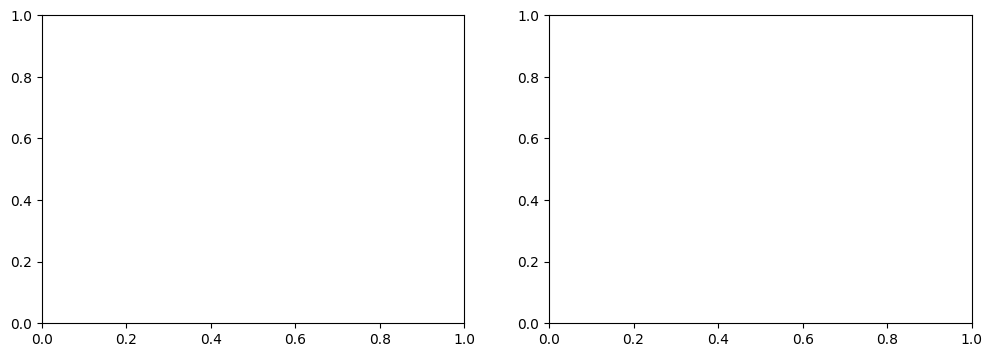

In [16]:
# ── Task 5 ──────────────────────────────────────────────────────────
z_vals = np.linspace(0.5, 6.0, 80)

E_gnn_1d, E_pyscf_1d = [], []
Fz_gnn_1d, Fz_pyscf_1d = [], []

for z in z_vals:
    pos = np.array([[0., 0., 0.], [0., 0., z]])
    # GNN energy and force component
    # --- your code here ---

    # PySCF energy and force component
    # --- your code here ---

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# --- your code here ---

### (Optional, only if you are fast) 2D potential map and force field

Let's push the study above more and try to do a scan in 2D.
Fix atom 1 at the origin.  Scan atom 2 over a 2D grid in the $xz$-plane: $x, z \in [-4, 4]$ Bohr.

**(a)** Compute the GNN energy $E(x, z)$ and forces $(F_x, F_z)$ at each grid point (skip points with $r < 0.6$ Bohr).

**(b)** Plot a quiver (arrow) plot of the force field, with the energy as a colour-filled contour background.  You can reuse the `plot_force_field_2d` function from notebook 2 of last week, or implement your own.

**(c)** On a second panel, compute and plot the **PySCF** force field on the same grid.

**What do you notice?**  Compare the two fields: where does the GNN deviate from PySCF?

**Hint:** reuse the grid setup from notebook 2:
```python
nx, nz  = 12, 12
x_vals  = np.linspace(-4, 4, nx)
z_vals  = np.linspace(-4, 4, nz)
x_grid, z_grid = np.meshgrid(x_vals, z_vals)
```

In [18]:
# ── Task 6 ──────────────────────────────────────────────────────────
nx, nz   = 12, 12
x_vals_g = np.linspace(-4., 4., nx)
z_vals_g = np.linspace(-4., 4., nz)
x_grid, z_grid = np.meshgrid(x_vals_g, z_vals_g)
min_dist = 0.6

E_grid_gnn   = np.full((nz, nx), np.nan)
F_grid_gnn   = np.full((nz, nx, 3), np.nan)
F_grid_pyscf = np.full((nz, nx, 3), np.nan)

# --- your code here: fill E_grid_gnn, F_grid_gnn, F_grid_pyscf ---

# Plot
# --- your code here ---

---
## Part 5 — Machine Learning Molecular Dynamics

We now have a fast force oracle — the trained GNN.  We will reuse the Velocity Verlet and Langevin integrators from notebook 2 of last week to run an NVT-MD simulation of $H_2$ at $T = 300$ K.

Try to benchmark how much faster we are today. What was the speed of a pyscf calculation fo the gradient, and what's the speed of the graph NN forces? What is the speedup compared to last week?

In [20]:
# ── Provided: Velocity Verlet and Langevin integrators (from nb 2) ──

def velocity_verlet_step(positions, velocities, forces, dt, mass, force_fn):
    '''One Velocity Verlet integration step.'''
    acc = forces / mass
    new_pos = positions + velocities * dt + 0.5 * acc * dt**2
    new_forces = force_fn(new_pos)
    new_acc = new_forces / mass
    new_vel = velocities + 0.5 * (acc + new_acc) * dt
    return new_pos, new_vel, new_forces


def langevin_verlet_step(positions, velocities, forces, dt, mass,
                         force_fn, gamma, temperature, rng):
    '''Velocity Verlet + BAOAB Langevin thermostat.'''
    # 1. Standard VV step
    new_pos, new_vel, new_forces = velocity_verlet_step(
        positions, velocities, forces, dt, mass, force_fn)
    # 2. Thermostat kick (BAOAB O step)
    alpha = np.exp(-gamma * dt)
    sigma = np.sqrt(K_BOLTZMANN * temperature / mass * (1.0 - alpha**2))
    xi    = rng.standard_normal(size=new_vel.shape)
    new_vel = alpha * new_vel + sigma * xi
    return new_pos, new_vel, new_forces


def mb_velocities(n_atoms, temperature, mass, rng):
    '''Sample initial velocities from Maxwell-Boltzmann distribution.'''
    sigma = np.sqrt(K_BOLTZMANN * temperature / mass)
    vel   = rng.normal(0.0, sigma, size=(n_atoms, 3))
    vel  -= vel.mean(axis=0)   # remove centre-of-mass drift
    return vel

In [ ]:
# ── Provided: GNN force function for H2 MD ──────────────────────────
# IMPORTANT: run this cell AFTER Task 4 (training) so that `params`
# refers to the trained weights.

@jax.jit
def _gnn_energy_h2_jit(params_arg, pos):
    return model.apply(params_arg, pos)


# ── Provided: GNN force function for H2 MD ──────────────────────────
# IMPORTANT: run this cell AFTER Task 4 (training) so that `params`
# refers to the trained weights.

def gnn_force_fn_h2(positions_real):
    '''GNN forces for H2.  positions_real: (2,3) -> forces: (2,3).'''
    forces_jax = -jax.grad(
        lambda p: model.apply(params, p)
    )(jnp.array(positions_real, dtype=jnp.float32))
    return np.array(forces_jax)

# Quick sanity check (force should be ~0 at equilibrium)
pos_eq = np.array([[0., 0., 0.], [0., 0., 1.4]], dtype=np.float32)
F_test = gnn_force_fn_h2(pos_eq)
E_test = model.apply(params, jnp.array(pos_eq))
print(f"E at r=1.4 Bohr : {E_test*EH_TO_MEV:.1f} meV")
print(f"F[0] at r=1.4   : {F_test[0]}  (should be ~0 at equilibrium)")


# More particles some random example
pos_eq = np.array([[0., 0., 0.], [0., 0., 1.4], [1., 0., 0.], [1., 0., 1.4], [-1., 0., 0.], [0., -1., 1.4]], dtype=np.float32)
F_test = gnn_force_fn_h2(pos_eq)
E_test = model.apply(params, jnp.array(pos_eq))
print(f"E at r=1.4 Bohr : {E_test*EH_TO_MEV:.1f} meV")
print(f"F[0] at r=1.4   : {F_test[0}  (should be ~0 at equilibrium)")


E at r=1.4 Bohr : -14645.0 meV
F[0] at r=1.4   : [-0.         -0.          0.03195112]  (should be ~0 at equilibrium)


### Task 7 — Run NVT-MD at $T = 300$ K

Write a simulation loop that:
1. Starts from $H_2$ near equilibrium with Maxwell-Boltzmann initial velocities
2. Runs `n_steps = 3000` Langevin steps (dt = 20 a.u. ≈ 0.5 fs)
3. Logs at every step: positions, velocities, GNN potential energy, kinetic energy

**Note:** — do not change the provided parameters, otherwise you won't get compatibility with the reference table.

**Hints:**
```python
KE = 0.5 * MASS_H * np.sum(velocities**2)
PE = float(_gnn_energy_h2_jit(jnp.array(positions)))
```

In [22]:
# ── Task 7 ──────────────────────────────────────────────────────────
T_target = 300.0       # K
gamma_LD = 1e-3        # friction coefficient (a.u.)^{-1}
dt       = 20.0        # time step (a.u.)
n_steps  = 3000
n_equil  = 500         # equilibration steps (discard for analysis)

rng_md   = np.random.default_rng(seed=314)

pos_init = np.array([[0., 0., -0.7], [0., 0.,  0.7]])   # near equilibrium
vel_init = mb_velocities(2, T_target, MASS_H, rng_md)

# Arrays for logging
traj_pos = np.zeros((n_steps + 1, 2, 3))
traj_vel = np.zeros((n_steps + 1, 2, 3))
KE_log   = np.zeros(n_steps)
PE_log   = np.zeros(n_steps)

traj_pos[0] = pos_init
traj_vel[0] = vel_init

positions  = pos_init.copy()
velocities = vel_init.copy()
forces     = gnn_force_fn_h2(positions)

# --- your code here: run the Langevin loop ---

time_au = np.arange(n_steps) * dt

## IMPORTANT! : The simulation above runs for only 2 atoms. 

After you've done the initial calculations and trajectory analysis, try to simulate a system with many more particles (~20/50/100/200...)

### Task 8 — Trajectory analysis

Compute and plot the following observables.  For each one, a hint is given.  After the plots, fill in the **comparison table** at the bottom.

**(a)** **Bond distance** $r(t) = |\mathbf{R}_0(t) - \mathbf{R}_1(t)|$ — plot as a time series in Å.

**(b)** **Kinetic temperature** $T_{\rm kin}(t)$:
$$T_{\rm kin}(t) = \frac{2\,E_{\rm kin}(t)}{3N\,k_B}$$
where $3N = 6$ for $N=2$.  Note: the Langevin thermostat here applies independent noise kicks to **all** atom velocity components, so the centre-of-mass velocity thermalises too — all $3N$ degrees of freedom are active.  Plot as a time series; mark the target $T=300$ K.

**(c)** **Pair distribution function** $g(r)$: normalised histogram of $r(t)$ over the *production* run (steps $n_{\rm equil}$ to end).  Plot and identify the peak.

**(d)** Compute the **mean bond length** $\langle r \rangle$ and **mean kinetic temperature** $\langle T_{\rm kin}\rangle$ over the production run, and fill in the table:

| Quantity | Experimental | PySCF RHF/STO-3G | GNN-MD (your result) |
|---|---|---|---|
| $r_{\rm eq}$ (Å) | 0.741 | 0.735 | — |
| $\langle r \rangle$ at 300 K (Å) | ~0.75 | ~0.74 | |
| $\langle T_{\rm kin}\rangle$ (K) | 300 (set) | — | |


In [24]:
# ── Task 8 ──────────────────────────────────────────────────────────
# (a) Bond distance time series
r_traj = np.linalg.norm(traj_pos[1:, 0] - traj_pos[1:, 1], axis=1) * BOHR_TO_ANG

# (b) Kinetic temperature  (3N = 6 DOF — Langevin thermostat acts on all components)
# Hint: T_kin = 2*KE / (3 * N_atoms * K_BOLTZMANN)  with N_atoms = 2
# --- your code here ---

# (c) Radial distribution function (production run only)
r_prod = r_traj[n_equil:]
# Hint: counts, bin_edges = np.histogram(r_prod, bins=50, density=True)
# bin_centres = 0.5*(bin_edges[:-1] + bin_edges[1:])

# --- your code here: three-panel plot ---

# (d) Print mean values
print(f"Mean bond length   <r>     = {r_prod.mean():.4f} Å")
# print(f"Mean kin. temp.    <T_kin> = {T_kin[n_equil:].mean():.1f} K")  # uncomment after computing T_kin


Mean bond length   <r>     = 0.7118 Å


---
### Extension Task 8d — Vibrational frequency from the VACF *(harder)*

The **velocity autocorrelation function (VACF)** encodes the vibrational spectrum:
$$C(\tau) = \frac{1}{T-\tau}\int_0^{T-\tau} \mathbf{v}(t) \cdot \mathbf{v}(t+\tau)\,dt$$

Its Fourier transform — the **vibrational density of states (VDOS)** — peaks at the characteristic vibrational frequencies.  For H$_2$, the dominant peak is the H–H stretch at $\approx 4401\,\text{cm}^{-1}$ (experimental) / $\approx 4200\,\text{cm}^{-1}$ (RHF/STO-3G classical MD).

**Steps:**
1. Compute the VACF $C(\tau)$ from the production-run velocities using `np.correlate` or a manual loop.
2. Window the VACF with a Hann window to reduce spectral leakage.
3. Fourier-transform: `S = np.abs(np.fft.rfft(C * window))`
4. Convert frequency axis to cm$^{-1}$: $\tilde\nu = \omega / (2\pi c)$ with $\omega = 2\pi k / (N\,\Delta t)$ and $1\,\text{a.u. freq} = 219474.6\,\text{cm}^{-1}$.
5. Plot $S(\tilde\nu)$ and identify the peak.

**Hint:** use longer trajectories (increase `n_steps` to 6000 or more) for better frequency resolution.  The frequency resolution is $\Delta\tilde\nu = 1/(N\,\Delta t) \times AU\_FREQ\_CM1$.

In [26]:
# ── Extension Task 8d ───────────────────────────────────────────────
# Use velocities from traj_vel (production run: indices n_equil onwards)
vel_prod = traj_vel[n_equil+1:]   # (n_prod, 2, 3)

# (1) VACF: C(lag) = mean over atoms of  sum_t v(t) · v(t+lag)
# Hint: flatten to (n_prod, n_atoms*3), use np.correlate on each component
# --- your code here ---

# (2) Window
# --- your code here ---

# (3) FFT
# --- your code here ---

# (4) Frequency axis in cm^{-1}
# Hint: dt_au = dt (in a.u.)
#       freqs = np.fft.rfftfreq(len(C), d=dt_au) * AU_FREQ_CM1  (in 1/a.u. units)
#       actually: freqs_cm1 = np.fft.rfftfreq(len(C), d=1.0) / (dt_au / AU_FREQ_CM1) ??
# More carefully:
#   delta_t = dt   (a.u.)
#   omega_k = 2*pi*k / (N*delta_t)   (a.u. angular frequency)
#   nu_cm1  = omega_k / (2*pi) * AU_FREQ_CM1
#   => nu_cm1 = k/(N*delta_t) * AU_FREQ_CM1
#   => nu_cm1 = np.fft.rfftfreq(N, d=delta_t) * AU_FREQ_CM1

# (5) Plot
# --- your code here ---

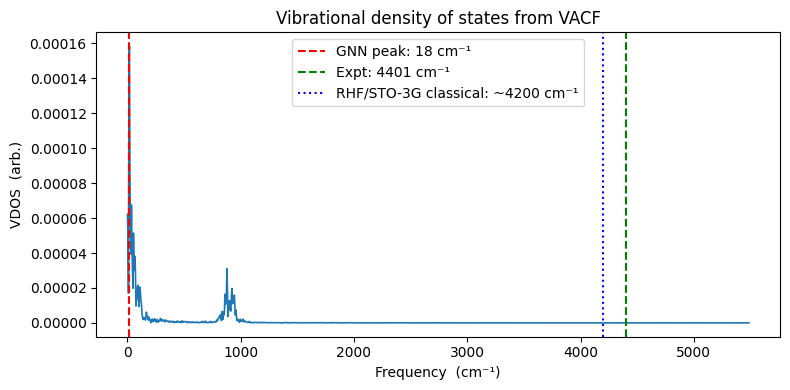

GNN-MD vibrational frequency: 18 cm⁻¹
Experimental H2 stretch:      4401 cm⁻¹


In [27]:
# === SOLUTION 8d ===
vel_prod = traj_vel[n_equil+1:]       # (n_prod, 2, 3)
n_prod   = len(vel_prod)
v_flat   = vel_prod.reshape(n_prod, -1)  # (n_prod, 6)

# (1) VACF via FFT (fast O(N log N) method)
#     C(tau) = IFFT( |FFT(v)|^2 ) / (N - lag)
from numpy.fft import fft, ifft
N    = n_prod
v_fft = fft(v_flat, n=2*N, axis=0)           # zero-padded
power = np.sum(np.abs(v_fft)**2, axis=1)      # sum over DOF
c_raw = np.real(ifft(power))[:N]              # (N,)
norms = N - np.arange(N, dtype=float)
C_vacf = c_raw / norms

# (2) Hann window to reduce spectral leakage
window = np.hanning(N)
C_win  = C_vacf * window

# (3-4) FFT and frequency axis
S_vdos   = np.abs(np.fft.rfft(C_win))
freqs_cm1 = np.fft.rfftfreq(N, d=dt) * AU_FREQ_CM1  # dt in a.u.

# (5) Plot (restrict to 0-8000 cm^-1)
mask_freq = freqs_cm1 < 8000
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(freqs_cm1[mask_freq], S_vdos[mask_freq], lw=1.2)
peak_freq = freqs_cm1[mask_freq][np.argmax(S_vdos[mask_freq])]
ax.axvline(peak_freq, color='r', ls='--', label=f'GNN peak: {peak_freq:.0f} cm⁻¹')
ax.axvline(4401, color='g', ls='--', label='Expt: 4401 cm⁻¹')
ax.axvline(4200, color='b', ls=':', label='RHF/STO-3G classical: ~4200 cm⁻¹')
ax.set_xlabel('Frequency  (cm⁻¹)'); ax.set_ylabel('VDOS  (arb.)')
ax.set_title('Vibrational density of states from VACF')
ax.legend(); plt.tight_layout(); plt.show()
print(f"GNN-MD vibrational frequency: {peak_freq:.0f} cm⁻¹")
print(f"Experimental H2 stretch:      4401 cm⁻¹")